Feature matrix shape: (150, 4)
Number of samples: 150
Number of features: 4

First 5 feature samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Labels shape: (150,)
Unique label values: [0 1 2]
First 5 labels: [0 0 0 0 0]


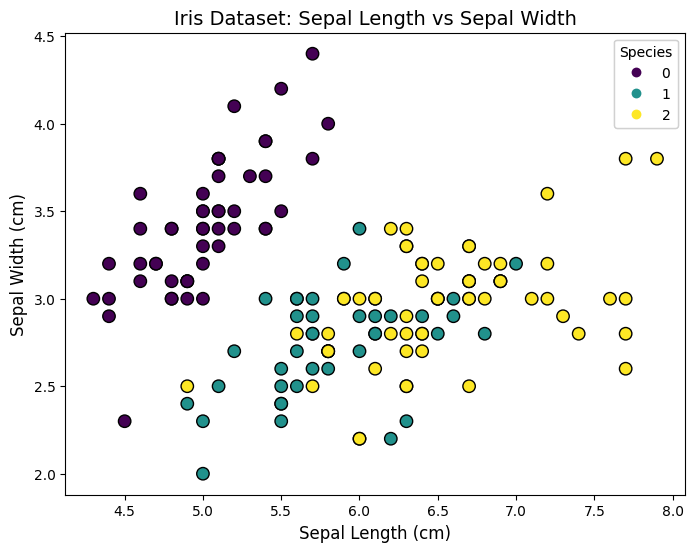

In [ ]:
# Task 2.1 - Importing files (Fisher Iris Dataset) and basic visualisation

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Load the dataset from the working directory
Iris_data = np.load("Iris_data.npy")       # Feature matrix
Iris_labels = np.load("Iris_labels.npy")   # Class labels

# Display dataset information
print("Feature matrix shape:", Iris_data.shape)
print("Number of samples:", Iris_data.shape[0])
print("Number of features:", Iris_data.shape[1])
print("\nFirst 5 feature samples:\n", Iris_data[:5])

print("\nLabels shape:", Iris_labels.shape)
print("Unique label values:", np.unique(Iris_labels))
print("First 5 labels:", Iris_labels[:5])

# Select two features for visualization
# For example: Feature 0 = Sepal length, Feature 1 = Sepal width
x_feature = 0  # Sepal length
y_feature = 1  # Sepal width

# Create scatter plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    Iris_data[:, x_feature],       # X-axis feature
    Iris_data[:, y_feature],       # Y-axis feature
    c=Iris_labels,                 # Color points by label
    cmap='viridis',                # Colormap for visual distinction
    edgecolor='k',                 # Black edges for clarity
    s=80                           # Marker size
)

# Label axes and title
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.title('Iris Dataset: Sepal Length vs Sepal Width', fontsize=14)

# Add legend mapping colors to classes
legend1 = plt.legend(
    *scatter.legend_elements(),
    title="Species"
)
plt.gca().add_artist(legend1)

# Display plot
plt.show()


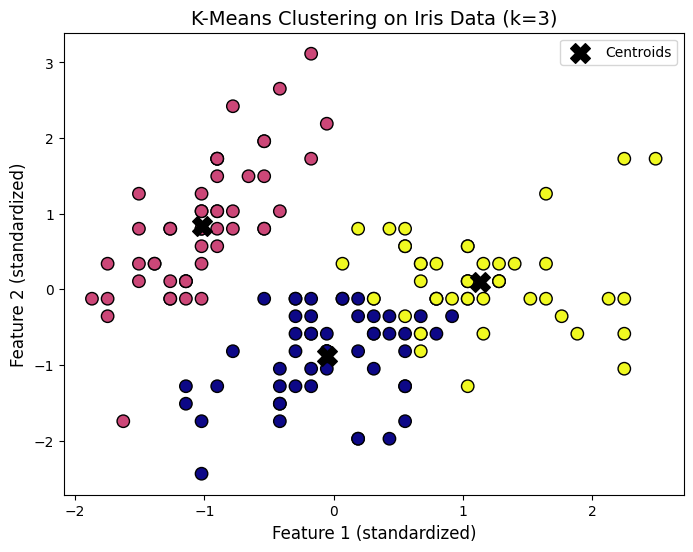

In [ ]:
# Task 2.2 - K Means Clustering

# === Standardize the data ===
scaler = StandardScaler()
Iris_scaled = scaler.fit_transform(Iris_data)

# === Initialize a KMeans object ===
# Let's start with k=3 (since there are 3 species in the Iris dataset)
kmeans = KMeans(
    n_clusters=3,       # Number of clusters to find
    init='k-means++',   # Smart centroid initialization method (default)
    n_init=10,          # Number of times the algorithm runs with different centroid seeds
    max_iter=300,       # Maximum number of iterations per run
    random_state=42     # For reproducibility
)

# === Fit the model to the data ===
kmeans.fit(Iris_scaled)

# === Predict cluster membership for each sample ===
cluster_labels = kmeans.predict(Iris_scaled)

# === Retrieve the cluster centroids ===
centroids = kmeans.cluster_centers_

# === Scatter plot to visualize clustering ===
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    Iris_scaled[:, 0],
    Iris_scaled[:, 1],
    c=cluster_labels,
    cmap='plasma',
    edgecolor='k',
    s=80
)

# Plot cluster centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title("K-Means Clustering on Iris Data (k=3)", fontsize=14)
plt.xlabel("Feature 1 (standardized)", fontsize=12)
plt.ylabel("Feature 2 (standardized)", fontsize=12)
plt.legend()
plt.show()


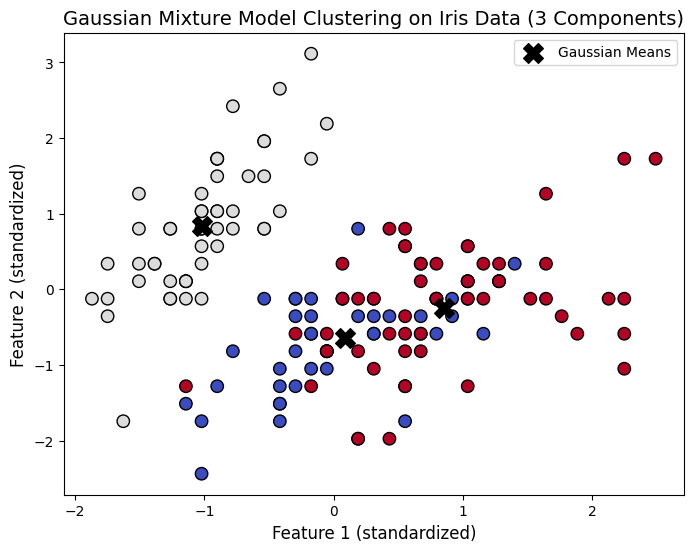

Unique GMM cluster labels: [0 1 2]


In [ ]:
# Task 2.3 - Gaussian Mixture Models

# === Initialize Gaussian Mixture Model (GMM) ===
# We'll start with 3 components (like the 3 iris species)
gmm = GaussianMixture(
    n_components=3,          # Number of clusters
    covariance_type='full',  # Each cluster has its own general covariance matrix
    n_init=10,               # Number of initializations (best one kept)
    random_state=42
)

# === Fit the model to the data ===
gmm.fit(Iris_scaled)

# === Predict cluster membership for each sample ===
gmm_labels = gmm.predict(Iris_scaled)

# === Retrieve Gaussian component means (in standardized feature space) ===
gmm_means = gmm.means_

# === Plot the GMM clustering results ===
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    Iris_scaled[:, 0],
    Iris_scaled[:, 1],
    c=gmm_labels,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)

# Plot Gaussian means as black X markers
plt.scatter(
    gmm_means[:, 0],
    gmm_means[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Gaussian Means'
)

plt.title("Gaussian Mixture Model Clustering on Iris Data (3 Components)", fontsize=14)
plt.xlabel("Feature 1 (standardized)", fontsize=12)
plt.ylabel("Feature 2 (standardized)", fontsize=12)
plt.legend()
plt.show()

Posterior probability shape: (150, 3)
Example (first 5 samples):
 [[6.77946364e-44 1.00000000e+00 7.54795895e-35]
 [6.51120733e-31 1.00000000e+00 2.81253000e-28]
 [7.49496171e-36 1.00000000e+00 4.97663839e-30]
 [1.16388091e-31 1.00000000e+00 3.05305722e-26]
 [2.59541939e-46 1.00000000e+00 3.32282259e-35]]


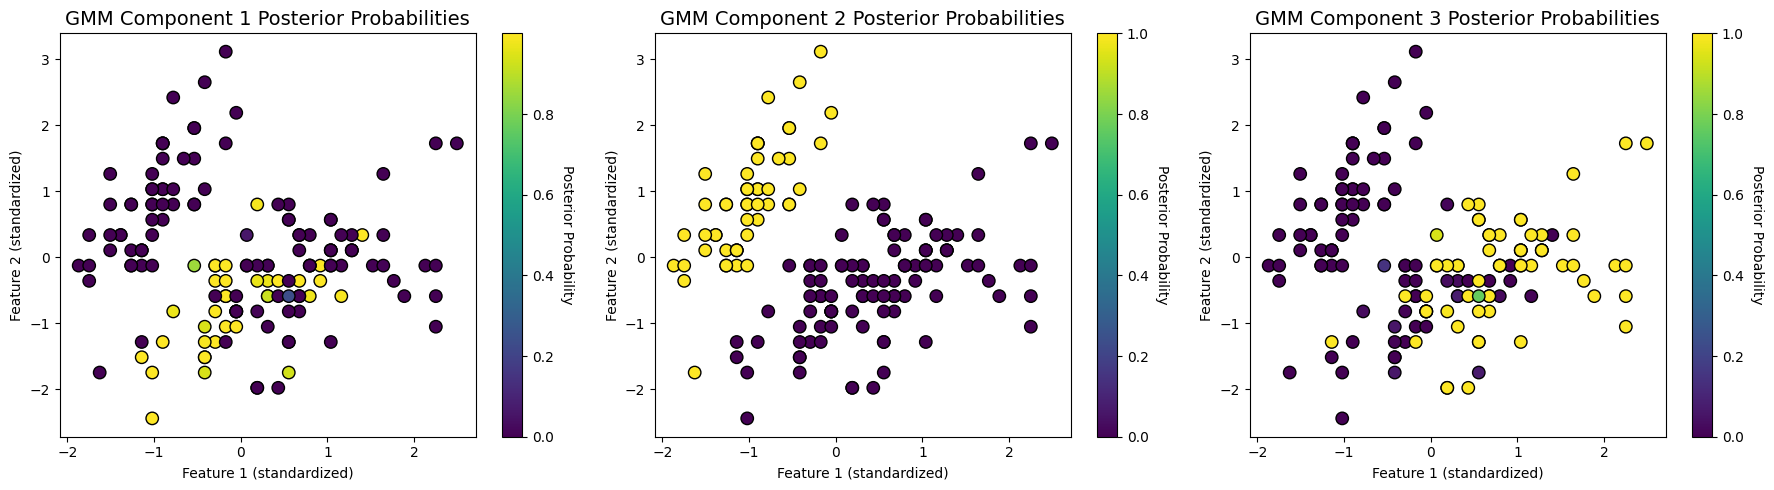

In [ ]:
# Task 2.3 - Gaussian Mixture Models

# === Compute posterior probabilities for each sample ===
# Returns a (150, 3) array where each column gives the probability of a point belonging to that component
posterior_probs = gmm.predict_proba(Iris_scaled)

print("Posterior probability shape:", posterior_probs.shape)
print("Example (first 5 samples):\n", posterior_probs[:5])

# === Plot posterior probabilities for each Gaussian component ===
n_components = gmm.n_components
fig, axes = plt.subplots(1, n_components, figsize=(18, 5))

for i in range(n_components):
    scatter = axes[i].scatter(
        Iris_scaled[:, 0],
        Iris_scaled[:, 1],
        c=posterior_probs[:, i],
        cmap='viridis',
        edgecolor='k',
        s=80
    )
    axes[i].set_title(f"GMM Component {i+1} Posterior Probabilities", fontsize=14)
    axes[i].set_xlabel("Feature 1 (standardized)")
    axes[i].set_ylabel("Feature 2 (standardized)")
    cbar = plt.colorbar(scatter, ax=axes[i])
    cbar.set_label("Posterior Probability", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


Data shape: (100, 10)
First 5 rows:
 [[ -1.80398981  -4.09512605  -5.0253188    7.36569809   2.42258743
    5.29189383  -6.74486404  -9.30130833  -0.20340057  -2.821411  ]
 [  0.62631796  -4.25405505  -0.3319475  -10.46678667  -0.04903716
    3.46861606  -2.62423323  -4.89544881  -8.86515986   0.96944955]
 [  6.62214156   6.63147447   8.79460645   6.3439946   -8.90619327
    0.42620907   2.52999576   0.32507992  -3.23447955  -0.44927401]
 [ 10.11102382   1.31485151  -1.46368002  -8.32755408   7.96077165
    2.53682193   5.25670984   2.74698765  -3.41855142 -11.02414736]
 [ -2.54626683  -2.23214887  -6.5475132    9.5699943   -0.14045173
    6.66606882  -4.37363928  -9.1152043    1.80186932  -4.58733752]]


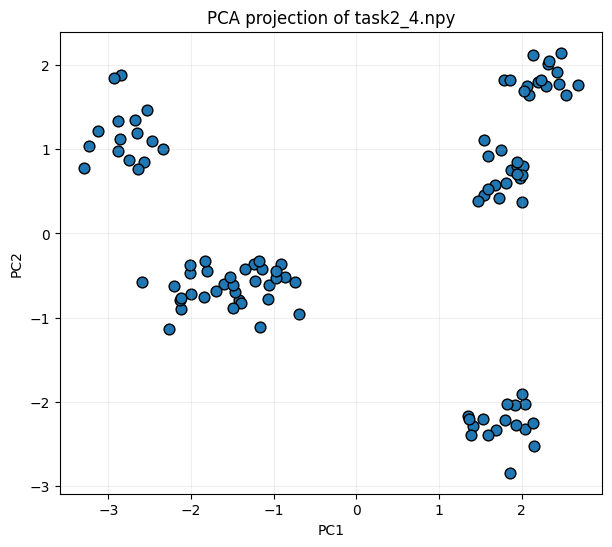

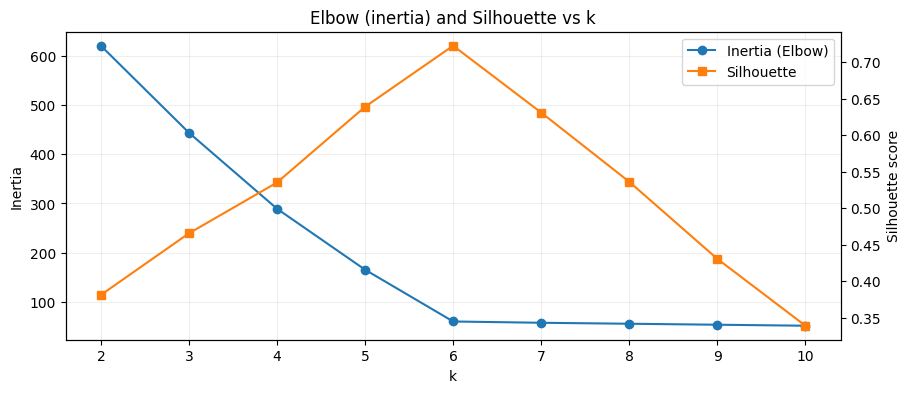

Silhouette scores by k: {2: np.float64(0.381), 3: np.float64(0.465), 4: np.float64(0.535), 5: np.float64(0.639), 6: np.float64(0.722), 7: np.float64(0.631), 8: np.float64(0.536), 9: np.float64(0.43), 10: np.float64(0.339)}
Cluster counts: Counter({np.int32(0): 50, np.int32(2): 33, np.int32(1): 17})
Silhouette score (KMeans): 0.4654


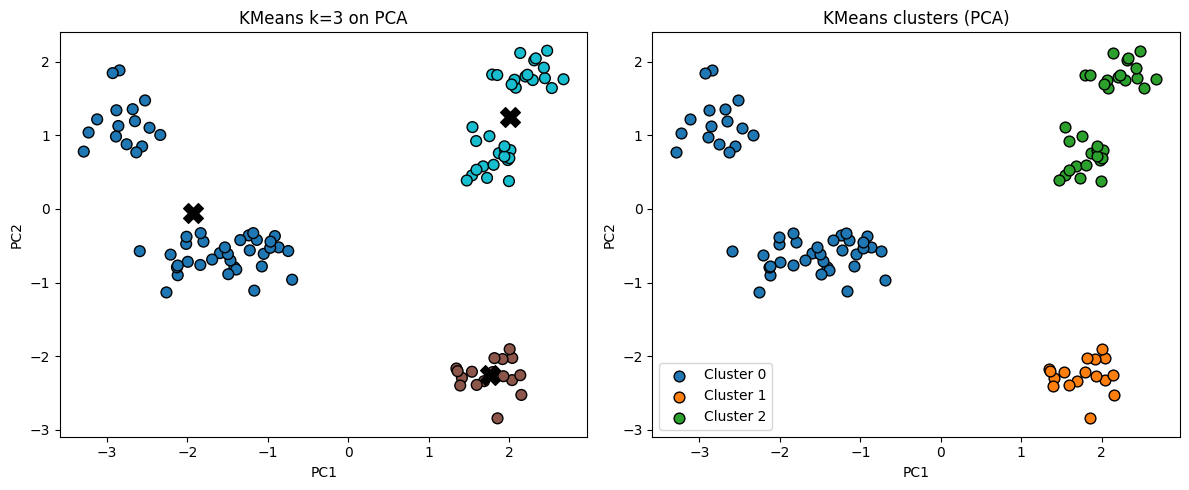

GMM component means (standardized feature space):
 [[-1.51521811 -0.81002486 -0.73620928  1.38363425  0.13135441  1.27205945
  -1.52638826 -1.35112764  0.96439402 -0.65213728]
 [ 0.89740563  0.87451471  0.38271441  0.13119699  0.37514375 -0.26511051
   0.90756393  0.90914032 -0.09827071 -0.42984204]
 [-0.60667035 -0.90486287 -0.21636389 -0.84405876 -0.61349583 -0.20874782
  -0.61635249 -0.70114628 -0.30931673  0.93900878]]
Silhouette score (GMM hard labels): 0.4315


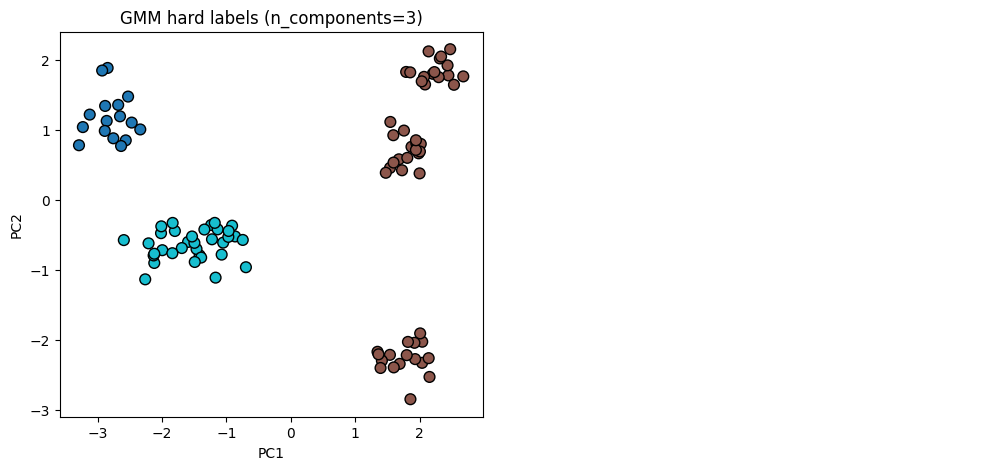

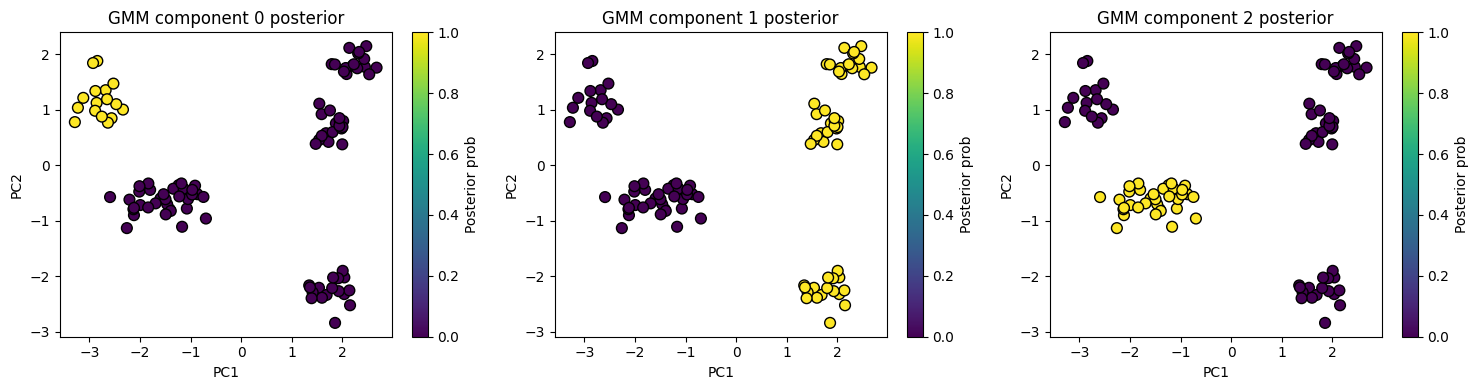

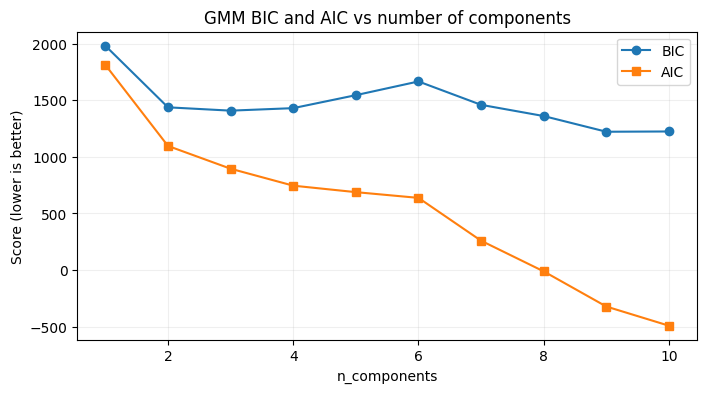

Best BIC at k= 9
Best AIC at k= 10


In [ ]:
# Clustering analysis for `task2_4.npy`

# This document contains a reproducible analysis (code + commentary) to:

#   1. Load `task2_4.npy` from the current working directory.
#   2. Explore the data and visualise it in 2D (PCA) for intuition.
#   3. Use repeated K-Means experiments (elbow + silhouette) to propose candidate cluster counts.
#   4. Fit K-Means and Gaussian Mixture Models (GMM) using all features and compare.
#   5. Use quantitative metrics (silhouette, inertia, BIC) and visual checks to help infer the true number of clusters

## 1) Load and inspect the data
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter

# Load data
data = np.load('task2_4.npy')
print('Data shape:', data.shape)

# Quick peek
print('First 5 rows:\n', data[:5])

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(data)

## 2) Quick 2D visualisation (PCA projection)

# 2D PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=60, edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection of task2_4.npy')
plt.grid(alpha=0.2)
plt.show()

## 3) Determine candidate k using Elbow (inertia) and Silhouette score (k=2..10)


Ks = list(range(2,11))
inertias = []
scores = []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    scores.append(sil)

# Plot
fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(Ks, inertias, '-o', label='Inertia (Elbow)')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.grid(alpha=0.2)
ax2 = ax1.twinx()
ax2.plot(Ks, scores, '-s', color='C1', label='Silhouette')
ax2.set_ylabel('Silhouette score')

lines, labels = [], []
for ax in (ax1, ax2):
    line, lab = ax.get_legend_handles_labels()
    lines += line
    labels += lab
ax1.legend(lines, labels, loc='best')
plt.title('Elbow (inertia) and Silhouette vs k')
plt.show()

print('Silhouette scores by k:', dict(zip(Ks, [round(s,3) for s in scores])))


# Look for an elbow in inertia and peak(s) in silhouette score. These suggest good candidate k values.

## 4) Fit K-Means and visualise clusters (choose k from above)

# Pick `k_candidate`** based on the previous plot. If multiple good values exist, try each.

k_candidate = 3  # <--- change this according to the result from step 3
km = KMeans(n_clusters=k_candidate, n_init=30, random_state=42)
km_labels = km.fit_predict(X)
centroids = km.cluster_centers_

# Visualise on PCA projection (colour by cluster)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='tab10', s=60, edgecolor='k')

# Project centroids to PCA space for display
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=200, c='black')
plt.title(f'KMeans k={k_candidate} on PCA')
plt.xlabel('PC1'); plt.ylabel('PC2')

# Show cluster sizes and silhouette

print('Cluster counts:', Counter(km_labels))

print('Silhouette score (KMeans):', round(silhouette_score(X, km_labels), 4))

plt.subplot(1,2,2)
for lbl in np.unique(km_labels):
    mask = (km_labels==lbl)
    plt.scatter(X_pca[mask,0], X_pca[mask,1], s=60, edgecolor='k', label=f'Cluster {lbl}')
plt.legend()
plt.title('KMeans clusters (PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## 5) Fit Gaussian Mixture Model (GMM) and visualise posterior probabilities

# Fit GMM with same number of components
gmm = GaussianMixture(n_components=k_candidate, covariance_type='full', n_init=10, init_params='kmeans', random_state=42)
gmm.fit(X)
gmm_labels = gmm.predict(X)
probs = gmm.predict_proba(X)  # shape (n_samples, k_candidate)
print('GMM component means (standardized feature space):\n', gmm.means_)
print('Silhouette score (GMM hard labels):', round(silhouette_score(X, gmm_labels), 4))

# Plot GMM hard labels on PCA
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap='tab10', s=60, edgecolor='k')
plt.title(f'GMM hard labels (n_components={k_candidate})')
plt.xlabel('PC1'); plt.ylabel('PC2')

# Posterior probability plots: one subplot per component
plt.subplot(1,2,2)
# We'll create small multipanel figure below instead
plt.axis('off')
plt.show()

# Posterior subplots
fig, axes = plt.subplots(1, k_candidate, figsize=(5*k_candidate, 4))
for i in range(k_candidate):
    ax = axes[i] if k_candidate>1 else axes
    sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=probs[:,i], cmap='viridis', s=60, edgecolor='k')
    ax.set_title(f'GMM component {i} posterior')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('Posterior prob')
plt.tight_layout()
plt.show()

# Posterior plots show soft assignments. Points with high values (close to 1) are confidently assigned.


## 6) Use BIC/AIC to compare GMM models with different n_components

Ks = list(range(1,11))
bics = []
aics = []
for k in Ks:
    g = GaussianMixture(n_components=k, covariance_type='full', n_init=5, init_params='kmeans', random_state=42)
    g.fit(X)
    bics.append(g.bic(X))
    aics.append(g.aic(X))

plt.figure(figsize=(8,4))
plt.plot(Ks, bics, '-o', label='BIC')
plt.plot(Ks, aics, '-s', label='AIC')
plt.xlabel('n_components')
plt.ylabel('Score (lower is better)')
plt.title('GMM BIC and AIC vs number of components')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print('Best BIC at k=', Ks[np.argmin(bics)])
print('Best AIC at k=', Ks[np.argmin(aics)])

# BIC typically penalizes model complexity more strongly than AIC; the minima indicate plausible number of mixture components.